In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

Text(0, 0.5, 'y dataset')

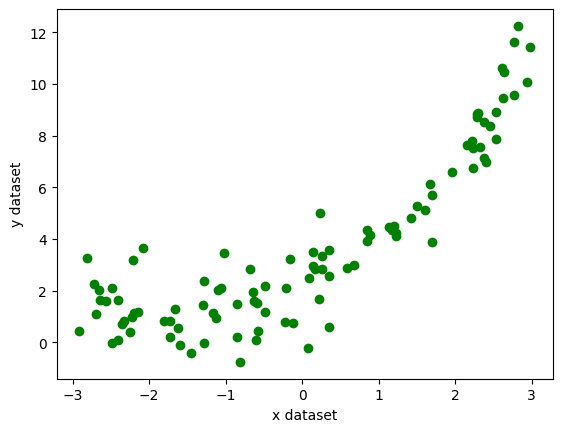

In [4]:
x = 6*np.random.rand(100,1) - 3
y = 0.5*x**2 + 1.5*x + 2 + np.random.randn(100,1)
## Quadractic equation is y = 0.5x^2 + 1.5x + 2+ outliers
plt.scatter(x,y,color ='g')
plt.xlabel('x dataset')
plt.ylabel('y dataset')

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)


In [6]:
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()
regression_1.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
from sklearn.metrics import mean_squared_error, r2_score
sscore = r2_score(y_test,regression_1.predict(X_test))
sscore

0.7321420600155113

Text(0, 0.5, 'y dataset')

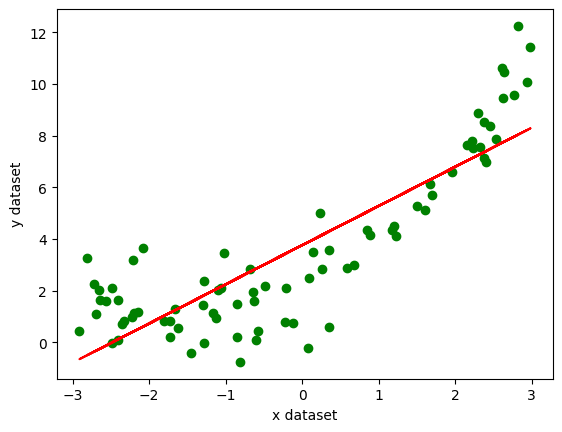

In [10]:
plt.plot(X_train,regression_1.predict(X_train),color = 'r')
plt.scatter(X_train,y_train,color = 'g')
plt.xlabel('x dataset')
plt.ylabel('y dataset')

In [23]:
## apply polynomial transformation to the dataset
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 3,include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [24]:
X_train_poly[:5]

array([[ 1.00000000e+00,  2.14948902e+00,  4.62030306e+00,
         9.93129069e+00],
       [ 1.00000000e+00,  8.84207170e-02,  7.81822320e-03,
         6.91292901e-04],
       [ 1.00000000e+00,  2.61017147e+00,  6.81299510e+00,
         1.77830854e+01],
       [ 1.00000000e+00, -2.40798437e+00,  5.79838875e+00,
        -1.39624295e+01],
       [ 1.00000000e+00,  2.23462649e+00,  4.99355556e+00,
         1.11587316e+01]])

In [25]:
X_test_poly[:5]

array([[ 1.00000000e+00, -2.24473683e+00,  5.03884343e+00,
        -1.13108774e+01],
       [ 1.00000000e+00,  8.41663999e-01,  7.08398287e-01,
         5.96233336e-01],
       [ 1.00000000e+00,  2.20243690e-01,  4.85072830e-02,
         1.06834230e-02],
       [ 1.00000000e+00,  1.13816619e+00,  1.29542228e+00,
         1.47440584e+00],
       [ 1.00000000e+00,  2.28747999e+00,  5.23256472e+00,
         1.19693871e+01]])

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,regression.predict(X_test_poly))
score

0.9195518948202622

In [27]:
regression.coef_

array([[0.        , 1.28887617, 0.50215759, 0.03098735]])

In [28]:
regression.intercept_


array([2.0248319])

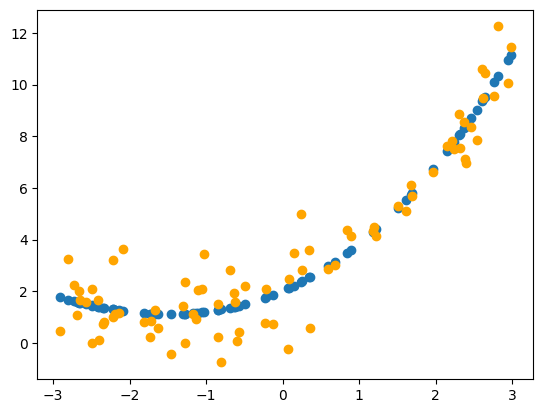

In [29]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train,color = 'orange')

In [33]:
# Prediction of new data set
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

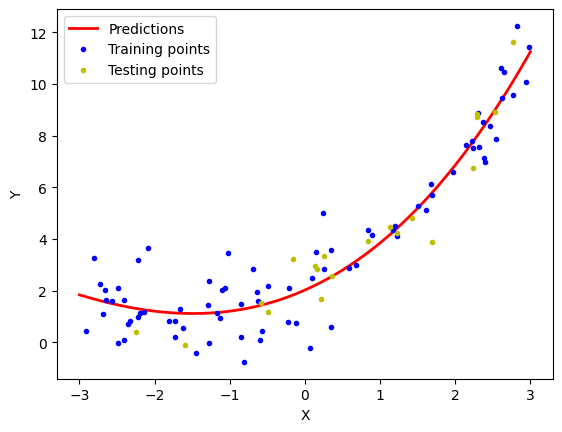

In [36]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new,'r-',linewidth = 2, label = "Predictions")
plt.plot(X_train,y_train,"b.",label = 'Training points')
plt.plot(X_test,y_test,'y.',label = 'Testing points')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

# Pipeline concepts

In [38]:
from sklearn.pipeline import Pipeline
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

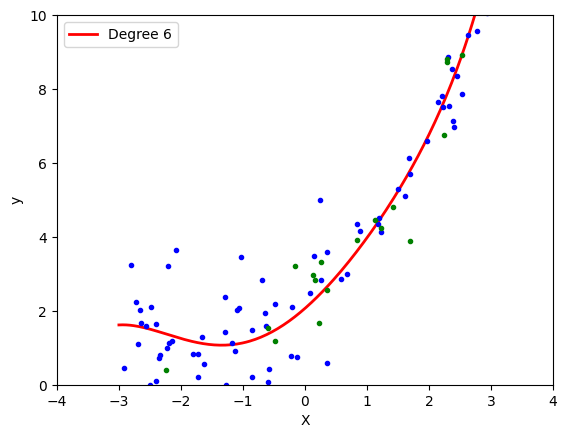

In [45]:
poly_regression(6)